# Import

In [71]:
#!pip install -r r.txt
import pandas as pd
import matplotlib.pyplot as plt
from skmultilearn.model_selection import IterativeStratification
from tensorflow.keras import layers, models
from collections import Counter
import numpy as np
import PIL
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import MultiLabelBinarizer
import os
import re, string
import pathlib  # 객체지향 방식으로 파일 경로를 다룸
import urllib.request # url을 통해 파일 다운로드 기능 제공
import tarfile
import nltk
import re
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Data

## Import Data

In [72]:
df = pd.read_csv('PubMed.csv').copy()

/tmp/ipykernel_1748/3118299677.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('PubMed.csv').copy()


In [73]:
import numpy as np
import tensorflow as tf
import random
import os

def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # GPU에서 실행 시 연산 순서에 따른 미세한 차이까지 제어 (선택 사항)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

# 시드 고정 실행
set_seeds(42)

## Clean Data

### Necessary Content

In [74]:
# 학습에 사용될 자료
df['Content'] = df['Title'].fillna('') + ": " + df['abstractText'].fillna('')
df['Content'].head()


,Content
0,Expression of p53 and coexistence of HPV in pr...
1,Vitamin D status in pregnant Indian women acro...
2,[Identification of a functionally important di...
3,Multilayer capsules: a promising microencapsul...
4,"Nanohydrogel with N,N'-bis(acryloyl)cystine cr..."


### Stopping Word 제거

In [75]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    if pd.isna(text): return ""
    words = text.split()
    filtered_words = [w for w in words if w.lower() not in stop_words]
    return " ".join(filtered_words)

df['Content'] = df['Content'].apply(remove_stopwords)
df['Content'].head()

,Content
0,Expression p53 coexistence HPV premalignant le...
1,Vitamin status pregnant Indian women across tr...
2,[Identification functionally important dipepti...
3,Multilayer capsules: promising microencapsulat...
4,"Nanohydrogel N,N'-bis(acryloyl)cystine crossli..."


---
### **MeSH 데이터 분류 체계 요약 (MeSH Data Classification Table)**

| 항목 (Term) | 한국어 명칭 (Korean) | 의미 (What: Semantic Domain) | 데이터 깊이 (Depth: Granularity) |
| :--- | :--- | :--- | :--- |
| **MeSH Root** (A-Z) | **MeSH 대분류** | 데이터가 속한 **가장 넓은 범위의 카테고리** (예: 질병, 화합물) | **Low (Level 1)**: 너무 포괄적이라 필터링 효율이 낮음 |
| **MeSH 3-Digit** (C08, C14 등) | **MeSH 중분류** (추출 타겟) | **특정 의학 전문 분야 (Domain)** 정의 (예: 호흡기계, 심혈관계) | **Medium (Level 2)**: 학습에 가장 적합한 **최적의 해상도** (Goldilocks Zone) |
| **MeSH Major** | **주요 주제어** | 논문에서 다루는 **핵심 키워드**들의 리스트 (인간이 읽기 좋은 텍스트) | **High (Specific)**: 매우 구체적이지만 데이터 희소성(Sparsity) 문제가 발생할 수 있음 |

---

In [76]:
# Mesh Subtitle 추출
# Mesh Subtitle = 논문 중분류 ()
def extract_3_digit_levels(mesh_data):
    # Alphabet + Letter + Letter 찾음
    codes = re.findall(r'[A-Z][0-9]{2}', str(mesh_data))
    # Return as a unique list to avoid duplicates for the same paper
    return list(set(codes))

df['mesh_sub_branches'] = df['meshid'].apply(extract_3_digit_levels)
df['is_pulmonary'] = df['mesh_sub_branches'].apply(lambda x: 1 if 'C08' in x else 0)

#df['mesh_sub_branches'].head()
print(df['is_pulmonary'].value_counts())

is_pulmonary
0    47217
1     1429
Name: count, dtype: int64


### Drop Other columns

In [77]:
df = df[['Content', 'is_pulmonary']].copy()

print(f"남은 컬럼: {df.columns.tolist()}")

남은 컬럼: ['Content', 'is_pulmonary']


### DF 확인

# Explatory Data Analysis

## 불균형 Data 확인

/tmp/ipykernel_1748/2950491239.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='is_pulmonary', palette='Set2')


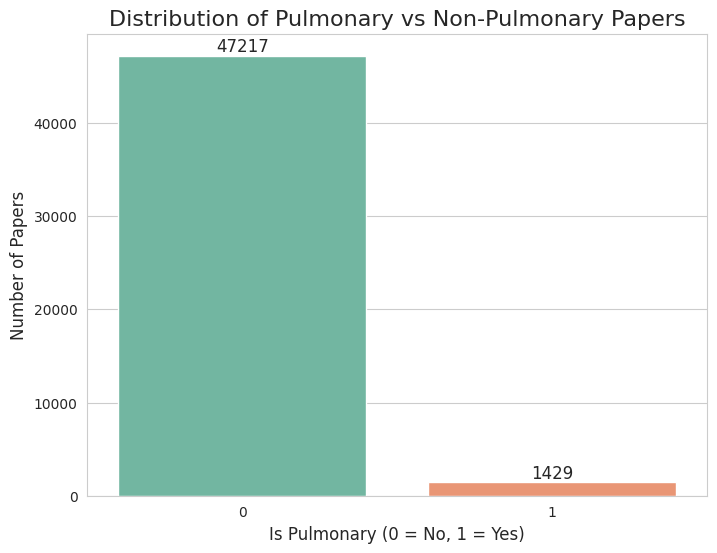

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# [GOOD EDA REASON]: This visually confirms the severe class imbalance.
# 딥러닝 모델이 다수 클래스(0)로 편향되는 것을 방지하기 위해 데이터의 불균형 정도를 시각적으로 확인합니다.
# 이 그래프를 통해 앞서 계산한 class_weight 가중치가 왜 필수적인지 증명할 수 있습니다.

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='is_pulmonary', palette='Set2')

plt.title('Distribution of Pulmonary vs Non-Pulmonary Papers', fontsize=16)
plt.xlabel('Is Pulmonary (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Number of Papers', fontsize=12)

# 막대 위에 정확한 수치 표시 (Annotate exact counts on bars)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.show()

## Content 길이 확인

=== Word Count Percentiles ===
count    48646.000000
mean        82.872816
std         76.869886
min          1.000000
50%         85.000000
75%        146.000000
90%        183.000000
95%        204.000000
99%        256.000000
max        705.000000
Name: word_count, dtype: float64


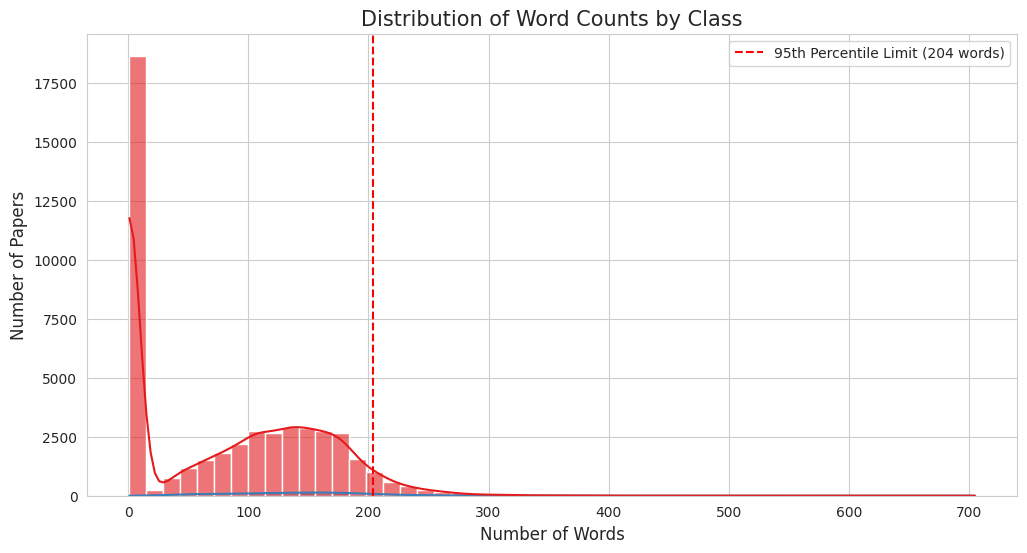

In [79]:
# 1. 각 논문(Content)의 단어 수 계산
df['word_count'] = df['Content'].apply(lambda x: len(str(x).split()))

# [GOOD EDA REASON]: TextVectorization 레이어의 `output_sequence_length`를
# 감으로 정하지 않고, 실제 데이터의 백분위수(90%, 95%)를 근거로 설정하기 위함입니다.
print("=== Word Count Percentiles ===")
print(df['word_count'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

# [BETTER ALTERNATIVE]: 클래스별 길이 분포 비교 (Compare lengths by class)
# 호흡기 질환 논문과 일반 논문 간에 텍스트 길이 차이가 있는지 확인합니다.
# 만약 한 쪽이 비정상적으로 짧다면 데이터 전처리 오류를 의심해볼 수 있습니다.
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='word_count', hue='is_pulmonary', bins=50, kde=True, palette='Set1', alpha=0.6)

# 권장되는 시퀀스 길이(예: 95백분위수)에 선 긋기
limit = int(df['word_count'].quantile(0.95))
plt.axvline(x=limit, color='red', linestyle='--', label=f'95th Percentile Limit ({limit} words)')

plt.title('Distribution of Word Counts by Class', fontsize=15)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Number of Papers', fontsize=12)
plt.legend()
plt.show()

## 희소성 확인

/tmp/ipykernel_1748/2581541578.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='Reds_r')


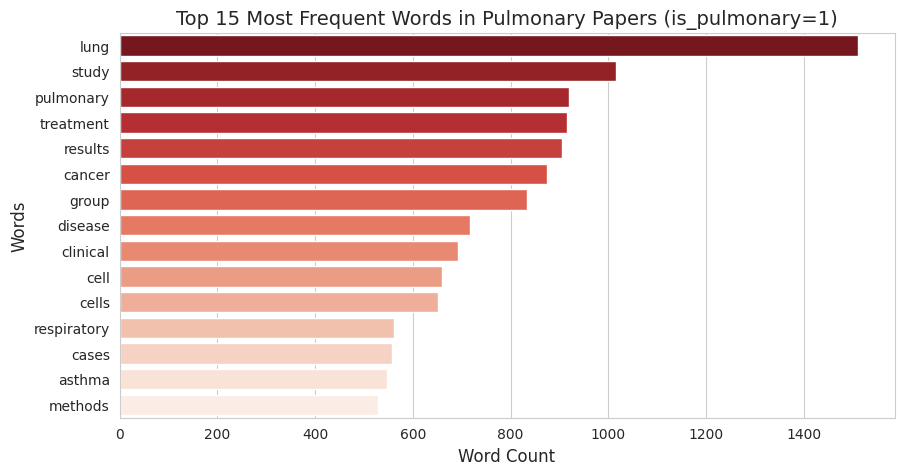

In [80]:
from collections import Counter
import re

# [GOOD EDA REASON]: 데이터셋의 품질 검증.
# 우리가 'is_pulmonary == 1'로 라벨링한 데이터가 실제로 호흡기/폐와 관련된
# 단어(lung, respiratory, asthma 등)를 많이 포함하고 있는지 검증(Sanity Check)합니다.

def get_top_words(text_series, top_n=20):
    # 모든 텍스트를 하나로 합치고 소문자 변환 및 알파벳만 추출
    text = " ".join(text_series.dropna().astype(str)).lower()
    words = re.findall(r'\b[a-z]{3,}\b', text) # 3글자 이상 단어만 추출

    # 불용어(Stopwords) 제거를 위한 임시 리스트
    basic_stopwords = {'the', 'and', 'of', 'in', 'to', 'with', 'for', 'was', 'were', 'that', 'this', 'are', 'from', 'patients'}
    words = [w for w in words if w not in basic_stopwords]

    return Counter(words).most_common(top_n)

# Pulmonary(1) 클래스에서 가장 많이 쓰인 단어 15개 추출
pulmonary_texts = df[df['is_pulmonary'] == 1]['Content']
top_pulmonary_words = get_top_words(pulmonary_texts, 15)

# 시각화
words, counts = zip(*top_pulmonary_words)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(words), palette='Reds_r')
plt.title('Top 15 Most Frequent Words in Pulmonary Papers (is_pulmonary=1)', fontsize=14)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.show()

## EDA column drop

In [81]:
# EDA용으로 만들었던 컬럼 삭제
df.drop(columns=['word_count'], inplace=True)

# Train Test Split

## X,y

In [82]:
X = df['Content'].values
y = df['is_pulmonary'].values

## Method

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

print(f"\nPulmonary ratio in Train: {np.mean(y_train) * 100:.2f}%")
print(f"Pulmonary ratio in Test: {np.mean(y_test) * 100:.2f}%")

Total samples: 48646
Training samples: 38916
Testing samples: 9730

Pulmonary ratio in Train: 2.94%
Pulmonary ratio in Test: 2.94%


## Text Vectorization

In [84]:
import tensorflow as tf
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# ==========================================
# 1. 텍스트 벡터화 레이어(TextVectorization) 정의
# ==========================================
# 딥러닝 모델은 텍스트를 직접 이해할 수 없으므로, 단어를 숫자로 바꿔주는 과정입니다.

# 가장 빈번하게 등장하는 상위 10,000개의 단어만 어휘 사전(Vocabulary)에 포함시킵니다.
max_tokens = 10000

# 앞선 EDA를 통해 결정한 문장의 최대 길이입니다.
# 200단어보다 짧은 문장은 빈자리를 0(패딩)으로 채우고, 긴 문장은 200단어까지만 자릅니다.
output_sequence_length = 200

vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',  # 각 단어를 고유한 정수 인덱스(예: 'lung' -> 5)로 변환합니다.
    output_sequence_length=output_sequence_length,
    ragged=False
)

# ==========================================
# 2. 어휘 사전(Vocabulary) 구축
# ==========================================
# 이 줄이 자연어 처리(NLP) 전처리에서 가장 중요한 부분 중 하나입니다.
# 모델은 오직 '학습 데이터(X_train)'에 있는 단어들만 보고 사전(Vocabulary)을 만들어야 합니다.
# (X_test가 포함되면 모델이 정답지를 미리 훔쳐보는 '데이터 누수(Data Leakage)'가 발생합니다.)
vectorize_layer.adapt(X_train)

# Model

## Model Constructor

In [85]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import f1_score

def build_model(model_type, num_classes=1):
    model = models.Sequential([
        vectorize_layer,
        layers.Embedding(input_dim=10000, output_dim=128, mask_zero=False),
    ])

    if model_type == 'bilstm':
        model.add(layers.Bidirectional(layers.LSTM(64)))
    elif model_type == 'gru':
        model.add(layers.Bidirectional(layers.GRU(64)))
    elif model_type == 'cnn':
        model.add(layers.Conv1D(128, 5, activation='relu'))
        model.add(layers.GlobalMaxPooling1D())

    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            'binary_accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

## Model 비교

In [86]:
model_names = ['bilstm', 'gru', 'cnn']
results = []

# Early Stopping 설정 (최적의 상태에서 멈추고 가중치 복원)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# y_train이 1차원 배열(0과 1)이라고 가정합니다.
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Keras가 이해할 수 있는 딕셔너리 형태로 변환 {0: weight_for_0, 1: weight_for_1}
class_weight_dict = dict(enumerate(weights))

print("Class weights:", class_weight_dict)



for name in model_names:
    tf.keras.backend.clear_session()
    set_seeds(42)
    print(f"\n--- Training Model: {name.upper()} ---")
    current_model = build_model(name)

    history = current_model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=64,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        class_weight=class_weight_dict,
        verbose=1
    )

    # Keras 내장 evaluate를 통한 정확한 평가
    eval_results = current_model.evaluate(X_test, y_test, verbose=0)

    # 모델 예측을 통한 F1-score (Macro/Micro) 계산
    y_pred_probs = current_model.predict(X_test, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int)

    f1_macro = f1_score(y_test, y_pred, average='macro')

    # 평가 지표 저장
    val_metrics = {
        'Model': name.upper(),
        'Val Loss': eval_results[0],
        'Val Accuracy': eval_results[1],
        'Val Precision': eval_results[2],
        'Val Recall': eval_results[3],
        'Val F1 (Macro)': f1_macro
    }
    results.append(val_metrics)

# 결과 비교 데이터프레임 생성
comparison_df = pd.DataFrame(results)
print("\n--- Model Comparison ---")
print(comparison_df.to_string(index=False))



Class weights: {0: np.float64(0.5151298546580891), 1: np.float64(17.023622047244096)}

--- Training Model: BILSTM ---
Epoch 1/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - binary_accuracy: 0.8649 - loss: 0.3420 - precision: 0.1571 - recall: 0.8250 - val_binary_accuracy: 0.9765 - val_loss: 0.1104 - val_precision: 0.5690 - val_recall: 0.8217
Epoch 2/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - binary_accuracy: 0.9560 - loss: 0.1476 - precision: 0.3949 - recall: 0.9388 - val_binary_accuracy: 0.8829 - val_loss: 0.2453 - val_precision: 0.1934 - val_recall: 0.9406
Epoch 3/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - binary_accuracy: 0.9661 - loss: 0.0988 - precision: 0.4633 - recall: 0.9764 - val_binary_accuracy: 0.9110 - val_loss: 0.2363 - val_precision: 0.2364 - val_recall: 0.9091
Epoch 4/20
609/609 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - binary_accuracy: 0.9744 - loss: 0.0676 - precision: 0.5343 - recall: 0.9886 - val_binary_accuracy: 0.9511 - val_loss: 0.1834 - val_precision: 0.3651

# Optimzation

## Batch size optimization

In [89]:
# 1. 방금 찾은 최적의 임계값을 설정합니다.
CHOSEN_THRESHOLD = 0.5

batch_sizes = [16, 32, 64, 128]
batch_results = []

for batch in batch_sizes:
    print(f"\n--- Testing Batch Size: {batch} ---")

    # 공정한 비교를 위해 모델을 매번 초기화
    test_model = build_model('cnn')

    history = test_model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=batch,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        class_weight=class_weight_dict,
        verbose=0 # 출력이 너무 길어지는 것을 방지
    )

    # 2. 최적 가중치가 복원된 모델에서 예측 확률 추출
    y_pred_probs = test_model.predict(X_test, verbose=0)

    # 3. 기본 0.5가 아닌, 우리가 선택한 최적의 임계값을 적용하여 평가!
    y_pred = (y_pred_probs > CHOSEN_THRESHOLD).astype(int)

    batch_results.append({
        'Batch Size': batch,
        'Val Loss': test_model.evaluate(X_test, y_test, verbose=0)[0],
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='binary', zero_division=0)
    })

batch_df = pd.DataFrame(batch_results)
print(f"\n--- Batch Size Comparison (Evaluated at Threshold: {CHOSEN_THRESHOLD}) ---")
print(batch_df.to_string(index=False))


--- Testing Batch Size: 16 ---

--- Testing Batch Size: 32 ---

--- Testing Batch Size: 64 ---

--- Testing Batch Size: 128 ---

--- Batch Size Comparison (Evaluated at Threshold: 0.5) ---
 Batch Size  Val Loss  Precision   Recall  F1-Score
         16  0.150568   0.306220 0.895105  0.456328
         32  0.199166   0.316290 0.930070  0.472050
         64  0.238076   0.296337 0.933566  0.449874
        128  0.070462   0.640541 0.828671  0.722561


### Visualizaton

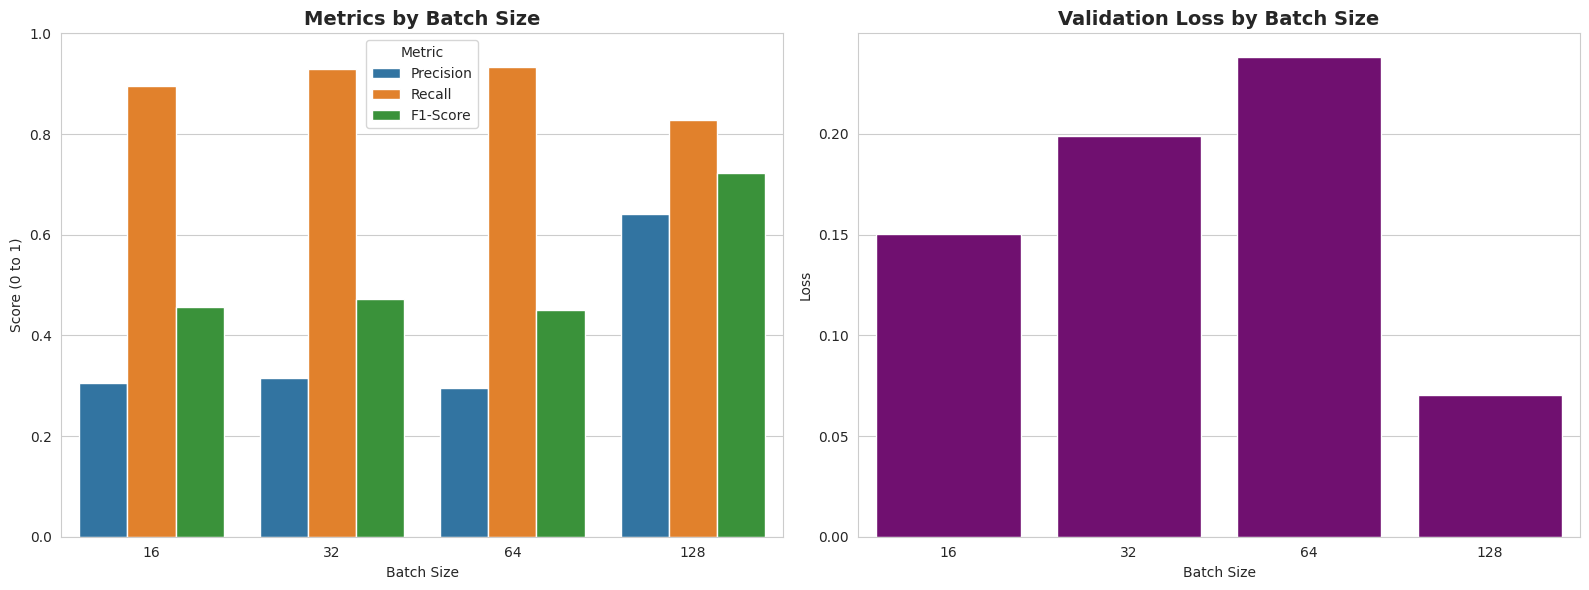

In [93]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 'Precision', 'Recall', 'F1-Score' 지표만 선택하여 Long-form으로 변환 (Melting)
# Val Loss는 스케일이 다르므로 별도로 그리는 것이 좋습니다.
df_metrics = batch_df.melt(
    id_vars='Batch Size',
    value_vars=['Precision', 'Recall', 'F1-Score'],
    var_name='Metric',
    value_name='Score'
)

# 2. 시각화 설정
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- [첫 번째 그래프: 지표 비교 (Grouped Bar Chart)] ---
sns.barplot(data=df_metrics, x='Batch Size', y='Score', hue='Metric', ax=ax1)
ax1.set_title('Metrics by Batch Size', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.set_ylabel('Score (0 to 1)')

# --- [두 번째 그래프: Validation Loss (Single Bar Chart)] ---
sns.barplot(data=batch_df, x='Batch Size', y='Val Loss', color='purple', ax=ax2)
ax2.set_title('Validation Loss by Batch Size', fontsize=14, fontweight='bold')
ax2.set_ylabel('Loss')

plt.tight_layout()
plt.show()

# Final Model

In [95]:
print("--- Training Final GRU Model ---")

BEST_BATCH_SIZE = 128
tf.keras.backend.clear_session()
final_cnn_model = build_model('cnn')

history = final_cnn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=BEST_BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

--- Training Final GRU Model ---
Epoch 1/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - binary_accuracy: 0.7743 - loss: 0.3957 - precision: 0.1010 - recall: 0.8460 - val_binary_accuracy: 0.9369 - val_loss: 0.2267 - val_precision: 0.3061 - val_recall: 0.9056
Epoch 2/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - binary_accuracy: 0.9524 - loss: 0.1530 - precision: 0.3761 - recall: 0.9431 - val_binary_accuracy: 0.9695 - val_loss: 0.1018 - val_precision: 0.4894 - val_recall: 0.8916
Epoch 3/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - binary_accuracy: 0.9794 - loss: 0.0570 - precision: 0.5882 - recall: 0.9921 - val_binary_accuracy: 0.9795 - val_loss: 0.0777 - val_precision: 0.6130 - val_recall: 0.8252


## Threshold Optimization

In [96]:
print("\n--- Final CNN Threshold Optimization ---")

# 3. 최종 모델의 예측 확률 추출
y_pred_probs_final = final_cnn_model.predict(X_test, verbose=0)

# 4. 임계값(Threshold) 다양하게 테스트 (0.1 ~ 0.9)
thresholds = np.arange(0.1, 0.95, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_pred_probs_final > t).astype(int)

    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, average='binary', zero_division=0)

    threshold_results.append({
        'Threshold': t,
        'Precision': p,
        'Recall': r,
        'F1-Score': f1
    })

# 5. 결과 비교 데이터프레임 출력
final_threshold_df = pd.DataFrame(threshold_results)
print(final_threshold_df.to_string(index=False))


--- Final CNN Threshold Optimization ---
 Threshold  Precision   Recall  F1-Score
      0.10   0.084135 0.979021  0.154953
      0.15   0.114592 0.972028  0.205015
      0.20   0.138959 0.961538  0.242826
      0.25   0.159437 0.951049  0.273092
      0.30   0.176664 0.937063  0.297282
      0.35   0.200454 0.926573  0.329602
      0.40   0.233512 0.916084  0.372159
      0.45   0.268873 0.909091  0.415004
      0.50   0.306147 0.905594  0.457597
      0.55   0.346720 0.905594  0.501452
      0.60   0.380531 0.902098  0.535270
      0.65   0.414911 0.895105  0.566999
      0.70   0.447972 0.888112  0.595545
      0.75   0.476460 0.884615  0.619339
      0.80   0.504000 0.881119  0.641221
      0.85   0.541667 0.863636  0.665768
      0.90   0.581731 0.846154  0.689459


### Visualization

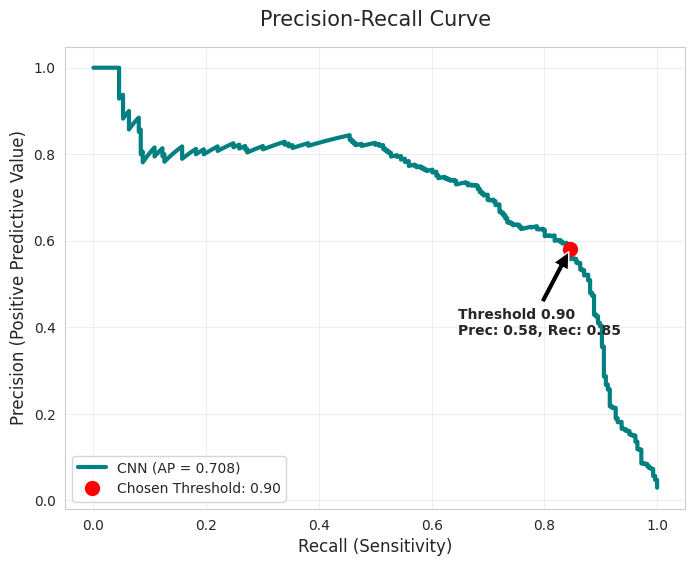

In [100]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. PR 곡선 데이터 계산
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs_final)
avg_precision = average_precision_score(y_test, y_pred_probs_final)

plt.figure(figsize=(8, 6))

# 2. PR 곡선 그리기
plt.plot(recall, precision, label=f'CNN (AP = {avg_precision:.3f})', color='teal', lw=3)

# 3. 0.9 임계값 지점 찾기 및 표시
# thresholds는 precision/recall보다 길이가 1 짧으므로 인덱싱에 주의
idx = (np.abs(thresholds - 0.90)).argmin()
plt.plot(recall[idx], precision[idx], 'ro', markersize=10, label='Chosen Threshold: 0.90')

# 주석 추가
plt.annotate(f'Threshold 0.90\nPrec: {precision[idx]:.2f}, Rec: {recall[idx]:.2f}',
             xy=(recall[idx], precision[idx]), xytext=(recall[idx]-0.2, precision[idx]-0.2),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, fontweight='bold')

plt.title('Precision-Recall Curve', fontsize=15, pad=15)
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

# Evaluation


--- Final Evaluation (Threshold: 0.9) ---
                   precision    recall  f1-score   support

Not Pulmonary (0)       1.00      0.98      0.99      9444
    Pulmonary (1)       0.58      0.85      0.69       286

         accuracy                           0.98      9730
        macro avg       0.79      0.91      0.84      9730
     weighted avg       0.98      0.98      0.98      9730



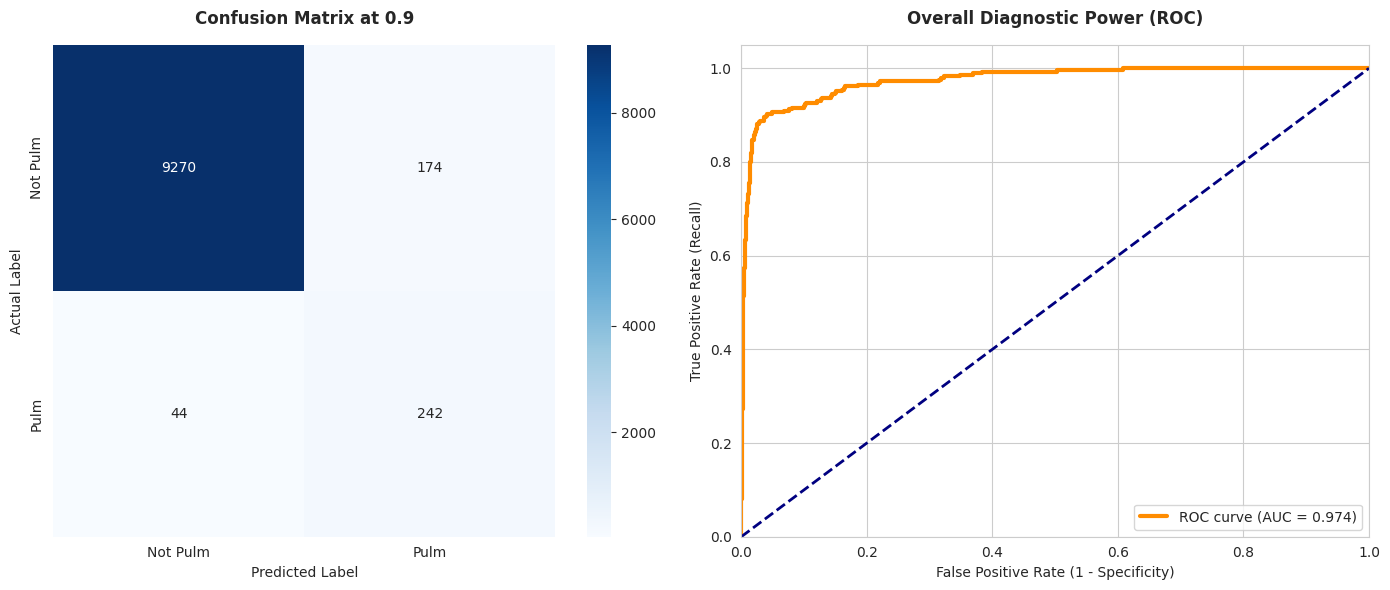

In [102]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 평가를 위한 세팅 (방금 결정하신 0.90 적용)
CHOSEN_THRESHOLD = 0.90

# ★ 중요: 'current_model'이 아닌 'final_cnn_model'을 사용하세요!
y_pred_probs = final_cnn_model.predict(X_test, verbose=0)
y_pred = (y_pred_probs > CHOSEN_THRESHOLD).astype(int)

# 2. Classification Report 출력
print(f"\n--- Final Evaluation (Threshold: {CHOSEN_THRESHOLD}) ---")
print(classification_report(y_test, y_pred, target_names=['Not Pulmonary (0)', 'Pulmonary (1)']))

# 3. 시각화 (Confusion Matrix & ROC Curve)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Confusion Matrix (임계값의 영향을 직접적으로 보여줍니다) ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Not Pulm', 'Pulm'], yticklabels=['Not Pulm', 'Pulm'])
ax1.set_title(f'Confusion Matrix at {CHOSEN_THRESHOLD}', fontweight='bold', pad=15)
ax1.set_ylabel('Actual Label')
ax1.set_xlabel('Predicted Label')

# --- ROC Curve (임계값과 상관없이 모델의 전체적인 성능을 보여줍니다) ---
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate (1 - Specificity)')
ax2.set_ylabel('True Positive Rate (Recall)')
ax2.set_title('Overall Diagnostic Power (ROC)', fontweight='bold', pad=15)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

# LIME

In [108]:
# 1. 라이브러리 설치 (Colab 기본 환경에 포함되어 있지 않습니다)
#!pip install lime

import lime
from lime.lime_text import LimeTextExplainer
import numpy as np
import tensorflow as tf

# 1. LIME을 위한 예측 래퍼 함수 수정
def predict_probabilities(texts):
    # LIME이 생성한 텍스트 리스트를 TensorFlow 문자열 텐서로 명시적 변환
    # 이 과정이 Keras 3의 'optree' dtype 에러를 해결합니다.
    text_tensor = tf.convert_to_tensor(texts, dtype=tf.string)

    # 모델 예측 (반드시 'final_cnn_model' 변수명을 확인하세요)
    preds = final_cnn_model.predict(text_tensor, verbose=0).flatten()

    # LIME 형식: [0일 확률, 1일 확률] 2차원 배열 반환
    return np.vstack([1 - preds, preds]).T

# 2. LIME Explainer 초기화
explainer = LimeTextExplainer(class_names=['Normal (0)', 'Pulmonary (1)'])

# 3. 설명할 텍스트 선택 (실제 환자 데이터 중 하나 선택)
# y_test가 1인 인덱스 중 첫 번째를 가져옵니다.
pos_indices = np.where(y_test == 1)[0]
idx_to_explain = pos_indices[0] if len(pos_indices) > 0 else 0

# 데이터 타입에 맞춰 안전하게 텍스트 추출
sample_text = X_test.iloc[idx_to_explain] if hasattr(X_test, 'iloc') else X_test[idx_to_explain]

print(f"Explaining instance {idx_to_explain} (True Class: 1)...")

# 4. 분석 실행
explanation = explainer.explain_instance(
    sample_text,
    predict_probabilities,
    num_features=10
)

# 5. 시각화 출력
explanation.show_in_notebook(text=True)

Explaining instance 30 (True Class: 1)...


# SHAP (Alt to LIME)

총 2개의 샘플 분석 중... (텍스트 길이에 따라 수십 초 정도 소요될 수 있습니다)


PermutationExplainer explainer: 3it [00:20, 10.06s/it]


[전체 샘플 중요도 요약]


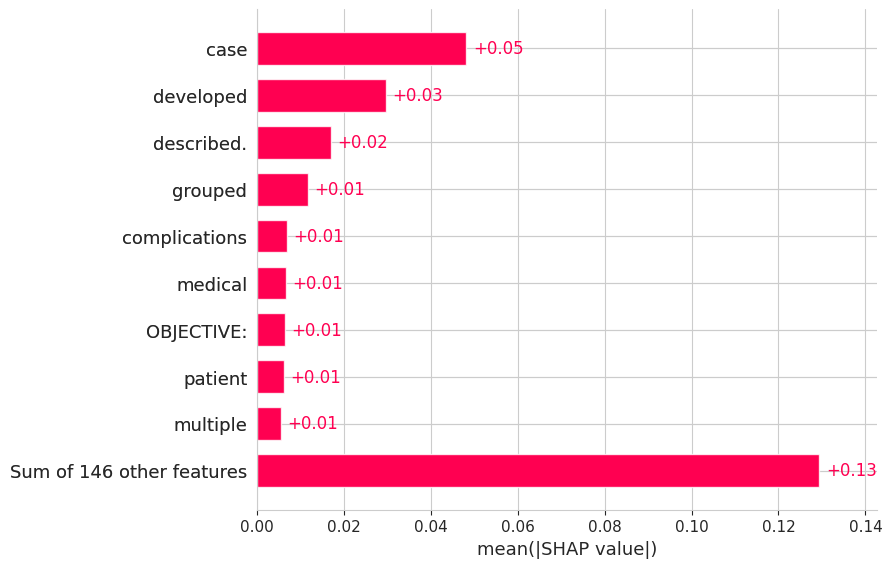


[첫 번째 샘플 상세 분석]


In [114]:
import shap
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. 예측 래퍼 함수 (Keras 3 대응)
def predict_for_shap(texts):
    if len(texts) == 0: return np.array([])
    text_tensor = tf.convert_to_tensor(texts, dtype=tf.string)
    preds = final_cnn_model.predict(text_tensor, verbose=0).flatten()
    return preds

# 2. 마스커 설정 (단어 단위 분리)
masker = shap.maskers.Text(tokenizer=r"\W+")

# 3. Explainer 초기화 (안정적인 permutation 알고리즘 사용)
explainer_shap = shap.Explainer(predict_for_shap, masker, algorithm="permutation")

# 4. 데이터 클리닝 (단어 2개 이상인 문장만 필터링)
def get_robust_samples(data, n=5):
    raw = data[:n].tolist() if hasattr(data, 'tolist') else list(data[:n])
    valid_samples = []
    for s in raw:
        clean_s = str(s).strip()
        if len(clean_s.split()) > 1:
            valid_samples.append(clean_s)
    return valid_samples

samples = get_robust_samples(X_test, n=5)

if not samples:
    print("분석할 유효한 샘플(단어 2개 이상)이 없습니다.")
else:
    print(f"총 {len(samples)}개의 샘플 분석 중... (텍스트 길이에 따라 수십 초 정도 소요될 수 있습니다)")

    shap_values_mult = explainer_shap(samples)

    # 6. 시각화
    print("\n[전체 샘플 중요도 요약]")
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_values_mult)

    print("\n[첫 번째 샘플 상세 분석]")
    shap.plots.text(shap_values_mult[0])